<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Convolutional_Neural_Networks_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Convolutional Neural Networks (CNN)**

<img src="https://editor.analyticsvidhya.com/uploads/18642architecture%20of%20cnn.png">

**Image source:** https://www.analyticsvidhya.com/blog/2022/01/convolutional-neural-networkcnn/



Convolutional Neural Networks (CNNs) are specialized deep learning models designed for processing structured grid data like images, utilizing convolutional layers to automatically learn spatial hierarchies of features. By using filters to scan input data, CNNs excel at image classification, object detection, and segmentation, making them standard in computer vision

This colab notebook will teach you CNNs **from scratch**, step by step.

By the end of this notebook, you will:
-  Understand **what a CNN is** and why it's useful
-  Build your **first CNN** to recognize handwritten digits
-  Train the model and see it **learn in real time**
-  Test the model on **new images**

---

### **Table of Contents**
1. What is a CNN? (The Intuition)
2. Setting Up - Installing & Importing Libraries
3. Loading the Dataset (MNIST Handwritten Digits)
4. Exploring the Data
5. Preparing the Data
6. Building the CNN Model
7. Training the Model
8. Evaluating the Model
9. Making Predictions
10. Summary & What's Next

---

## Part 1: What is a CNN? (The Intuition)

Imagine you're looking at a photo of a cat. 🐱

Your brain doesn't read every pixel one by one. Instead, it:
1. **Detects edges** (the outline of the cat)
2. **Recognizes shapes** (pointy ears, round face)
3. **Identifies the whole object** ("That's a cat!")

A **CNN (Convolutional Neural Network)** works the same way!

```
Image → Detect Edges → Detect Shapes → Detect Patterns → Classify
  🖼️  →     📐        →      🔷        →      🐱         →  "Cat!"
```

### Key Terms (Plain English)

| Term | What it means |
|------|---------------|
| **Convolution** | Sliding a small filter over the image to detect features |
| **Filter / Kernel** | A small grid (e.g., 3×3) that looks for a specific pattern |
| **Feature Map** | The result after applying a filter to an image |
| **Pooling** | Shrinking the image to keep only the important information |
| **Flatten** | Converting 2D image data into a 1D list |
| **Dense Layer** | A regular neural network layer (fully connected) |
| **Activation (ReLU)** | Turns negative values to 0 (adds non-linearity) |
| **Softmax** | Converts outputs to probabilities (adds up to 100%) |

## Part 2: Setting Up: Installing & Importing Libraries

In [ ]:
# Install any missing packages (usually already available in Colab)
# Run this cell first!

!pip install tensorflow matplotlib numpy --quiet
print("All packages are ready!")

All packages are ready!


In [ ]:
# Import the libraries we need
import numpy as np                        # For working with numbers and arrays
import matplotlib.pyplot as plt           # For making plots and showing images

import tensorflow as tf                   # The main deep learning library
from tensorflow import keras              # Keras = easy-to-use interface for TensorFlow
from tensorflow.keras import layers       # Building blocks for our neural network
from tensorflow.keras.datasets import mnist  # The dataset we'll use

# Check versions
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print("Ready to build a CNN!")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Ready to build a CNN!


## Part 3: Loading the Dataset: MNIST Handwritten Digits

We'll use the **MNIST dataset** — a classic beginner dataset.

- 📁 **70,000 images** of handwritten digits (0–9)
- Each image is **28×28 pixels**, grayscale (black and white)
- 60,000 for **training**, 10,000 for **testing**

Our goal: **Look at an image → Predict what digit it is**

In [ ]:
# Load the MNIST dataset
# Keras automatically downloads it for us!

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Let's see what we loaded
print("Dataset loaded!")
print(f"\n Training data:")
print(f"Images shape: {x_train.shape}  ← (60000 images, each 28x28 pixels)")
print(f"Labels shape: {y_train.shape}  ← (60000 labels, one per image)")

print(f"\n Testing data:")
print(f"Images shape: {x_test.shape}")
print(f"Labels shape: {y_test.shape}")

print(f"\n Label values range from: {y_train.min()} to {y_train.max()}")
print(f"(These are the digit classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9)")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset loaded!

 Training data:
Images shape: (60000, 28, 28)  ← (60000 images, each 28x28 pixels)
Labels shape: (60000,)  ← (60000 labels, one per image)

 Testing data:
Images shape: (10000, 28, 28)
Labels shape: (10000,)

 Label values range from: 0 to 9
(These are the digit classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9)


## Part 4: Exploring the Data

Before building anything, let's **see** what our data looks like!

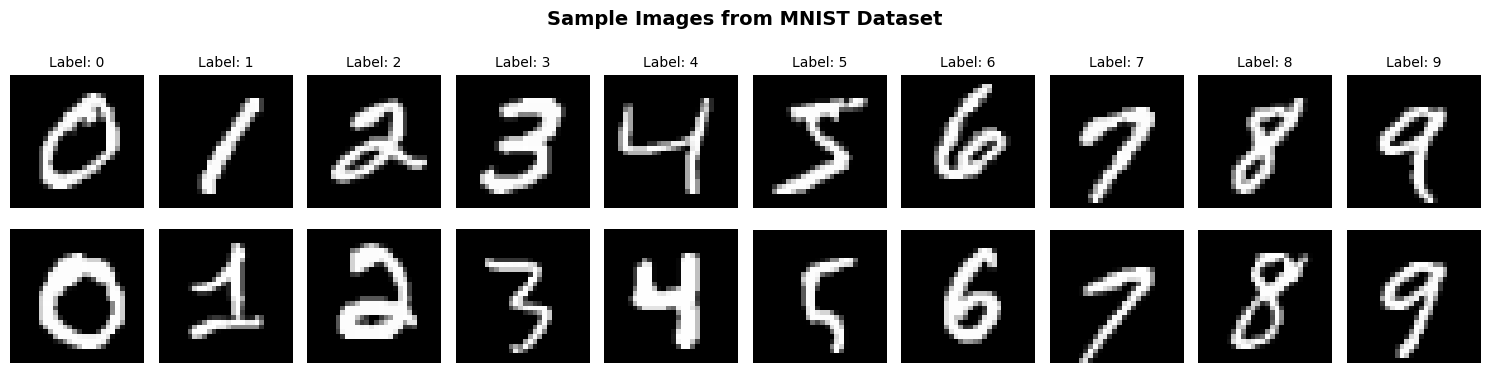

Each column shows two different examples of the same digit!


In [ ]:
# Let's look at some sample images

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle('Sample Images from MNIST Dataset', fontsize=14, fontweight='bold')

for i in range(10):
    # Find one example of each digit (0-9)
    idx = np.where(y_train == i)[0][0]

    # Top row: the image
    axes[0, i].imshow(x_train[idx], cmap='gray')
    axes[0, i].set_title(f'Label: {i}', fontsize=10)
    axes[0, i].axis('off')

    # Bottom row: another example
    idx2 = np.where(y_train == i)[0][5]
    axes[1, i].imshow(x_train[idx2], cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print("Each column shows two different examples of the same digit!")

This image has the label: 5
Image shape: (28, 28) (28 rows × 28 columns of pixels)
Pixel values range from: 0 to 255
  → 0 = black (background), 255 = white (digit)



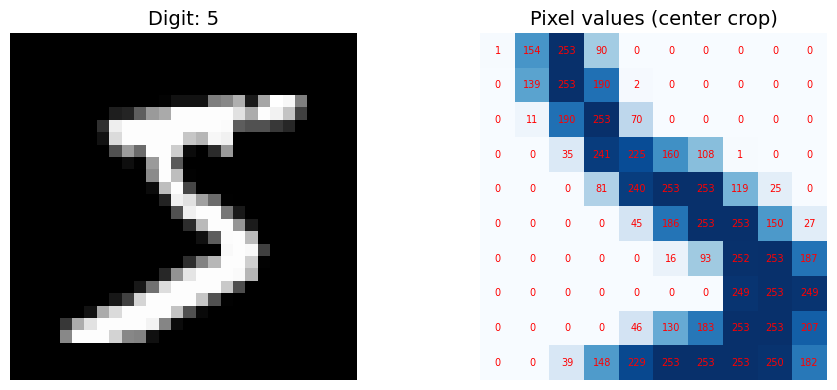

In [ ]:
# Zoom in on ONE image and see its pixel values
sample_image = x_train[0]
sample_label = y_train[0]

print(f"This image has the label: {sample_label}")
print(f"Image shape: {sample_image.shape} (28 rows × 28 columns of pixels)")
print(f"Pixel values range from: {sample_image.min()} to {sample_image.max()}")
print(f"  → 0 = black (background), 255 = white (digit)\n")

# Show the image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(sample_image, cmap='gray')
ax1.set_title(f'Digit: {sample_label}', fontsize=14)
ax1.axis('off')

# Show raw pixel values (zoomed in on center)
ax2.imshow(sample_image[10:20, 10:20], cmap='Blues')
for i in range(10):
    for j in range(10):
        ax2.text(j, i, str(sample_image[10+i, 10+j]),
                ha='center', va='center', fontsize=7, color='red')
ax2.set_title('Pixel values (center crop)', fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

## Part 5: Preparing the Data

Before feeding data into the CNN, we need to do a little preparation:

1. **Reshape** — Add a "channel" dimension (CNNs expect this)
2. **Normalize** — Scale pixel values from 0–255 to 0–1 (makes training easier)
3. **One-Hot Encode** — Convert labels like `5` to `[0,0,0,0,0,1,0,0,0,0]`

In [ ]:
# Step 1: Reshape — add channel dimension
# CNN expects: (batch_size, height, width, channels)
# Grayscale images have 1 channel. Color images (RGB) have 3 channels.

x_train = x_train.reshape(-1, 28, 28, 1)  # -1 means "keep the same count"
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f"After reshape:")
print(f"  x_train shape: {x_train.shape}  ← (60000, 28, 28, 1 channel)")

# Step 2: Normalize — scale pixel values to [0, 1]
# Why? Neural networks work better with small numbers!

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

print(f"\nAfter normalization:")
print(f"  Pixel values now range from: {x_train.min():.1f} to {x_train.max():.1f}")

# Step 3: One-Hot Encode labels
# Convert label '5' → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
# Each position represents one digit class (0-9)

num_classes = 10
y_train_ohe = keras.utils.to_categorical(y_train, num_classes)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes)

print(f"\n One-Hot Encoding example:")
print(f"Original label: {y_train[0]}")
print(f"One-hot label:  {y_train_ohe[0]}")
print("\n Data is ready for the CNN!")

After reshape:
  x_train shape: (60000, 28, 28, 1)  ← (60000, 28, 28, 1 channel)

After normalization:
  Pixel values now range from: 0.0 to 1.0

 One-Hot Encoding example:
Original label: 5
One-hot label:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

 Data is ready for the CNN!


## Part 6: Building the CNN Model

Now the exciting part! Let's build our CNN layer by layer.

### The Architecture:
```
INPUT (28×28×1)
    ↓
[Conv2D] → Detect low-level features (edges)
    ↓
[MaxPooling] → Shrink the image (keep important info)
    ↓
[Conv2D] → Detect higher-level features (shapes)
    ↓
[MaxPooling] → Shrink again
    ↓
[Flatten] → Convert 2D → 1D
    ↓
[Dense] → Learn combinations of features
    ↓
[Dense + Softmax] → Output 10 probabilities (one per digit)
    ↓
OUTPUT: "It's a 5!" (with 97% confidence)
```

In [ ]:
#  Build the CNN
model = keras.Sequential([

    # LAYER 1: First Convolutional Layer
    # 32 filters, each 3×3 pixels
    # activation='relu' → turns negative values to 0 (the model learns non-linear patterns)
    # input_shape = (height, width, channels)
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    # This layer slides 32 different 3×3 filters across the image
    # Each filter learns to detect something (edges, corners, curves...)

    # LAYER 2: First Pooling Layer
    # MaxPooling takes the MAX value in each 2×2 window → shrinks image by half
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Reduces 26×26 → 13×13. Keeps the strongest feature detected.

    # LAYER 3: Second Convolutional Layer
    # 64 filters this time — we go deeper, detecting more complex patterns
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),

    # LAYER 4: Second Pooling Layer
    layers.MaxPooling2D(pool_size=(2, 2)),
    #  ☝️ Reduces 11×11 → 5×5

    # LAYER 5: Flatten
    # Convert 3D feature maps → 1D vector
    # (5, 5, 64) → 1600 values in a single list
    layers.Flatten(),

    # LAYER 6: Dropout
    # Randomly "turn off" 50% of neurons during training
    # This PREVENTS overfitting (memorizing training data)
    layers.Dropout(0.5),

    # LAYER 7: Dense (Fully Connected) Layer
    # 128 neurons, each connected to all previous neurons
    # This is where the network "thinks" about what digit it sees
    layers.Dense(128, activation='relu'),

    # LAYER 8: Output Layer
    # 10 neurons → one for each digit class (0-9)
    # softmax → outputs probabilities that add up to 1.0
    layers.Dense(10, activation='softmax'),
    # e.g., output: [0.01, 0.01, 0.01, 0.01, 0.01, 0.93, 0.01, 0.00, 0.00, 0.01]
    #                    0     1     2     3     4    [5]    6     7     8     9
    #                                                 ↑ 93% sure it's a 5!
])

# Print a summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model — tell it HOW to learn
model.compile(
    optimizer='adam',                          # How to update weights (Adam is a popular choice)
    loss='categorical_crossentropy',           # How to measure mistakes (for classification)
    metrics=['accuracy']                       # What to track during training
)

print("Model compiled and ready to train!")
print()
print("What these mean:")
print("optimizer='adam'  → Adam finds the best path down the 'error hill'")
print("loss='categorical_crossentropy' → Measures how wrong our predictions are")
print("metrics=['accuracy'] → We also track % of correct predictions")

Model compiled and ready to train!

What these mean:
optimizer='adam'  → Adam finds the best path down the 'error hill'
loss='categorical_crossentropy' → Measures how wrong our predictions are
metrics=['accuracy'] → We also track % of correct predictions


## Part 7: Training the Model

Training = showing the model examples and letting it adjust its internal "knobs" (weights) to get better.

- **Epoch**: One complete pass through ALL training images
- **Batch size**: How many images to show at once before updating

We'll train for **5 epochs** — enough to see good results without waiting too long.

In [ ]:
# Train the model!
# This may take 2-5 minutes depending on GPU availability
print("Starting training...")
print("Watch how accuracy improves each epoch!\n")

history = model.fit(
    x_train, y_train_ohe,   # Training images and their correct labels
    batch_size=128,          # Process 128 images at a time
    epochs=10,               # Go through all data 10 times
    validation_split=0.1,    # Use 10% of training data to monitor overfitting
    verbose=1                # Show progress bar
)

print("\n Training complete!")

Starting training...
Watch how accuracy improves each epoch!

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9205 - loss: 0.2615 - val_accuracy: 0.9848 - val_loss: 0.0606
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0831 - val_accuracy: 0.9848 - val_loss: 0.0489
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.0635 - val_accuracy: 0.9898 - val_loss: 0.0362
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9834 - loss: 0.0523 - val_accuracy: 0.9908 - val_loss: 0.0339
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9849 - loss: 0.0460 - val_accuracy: 0.9898 - val_loss: 0.0329
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9874 - loss: 0.0382 - val_accuracy: 0.9915 - val_loss: 0.0305
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0352 - val_accuracy: 0.9907 - val_loss: 0.0287
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 

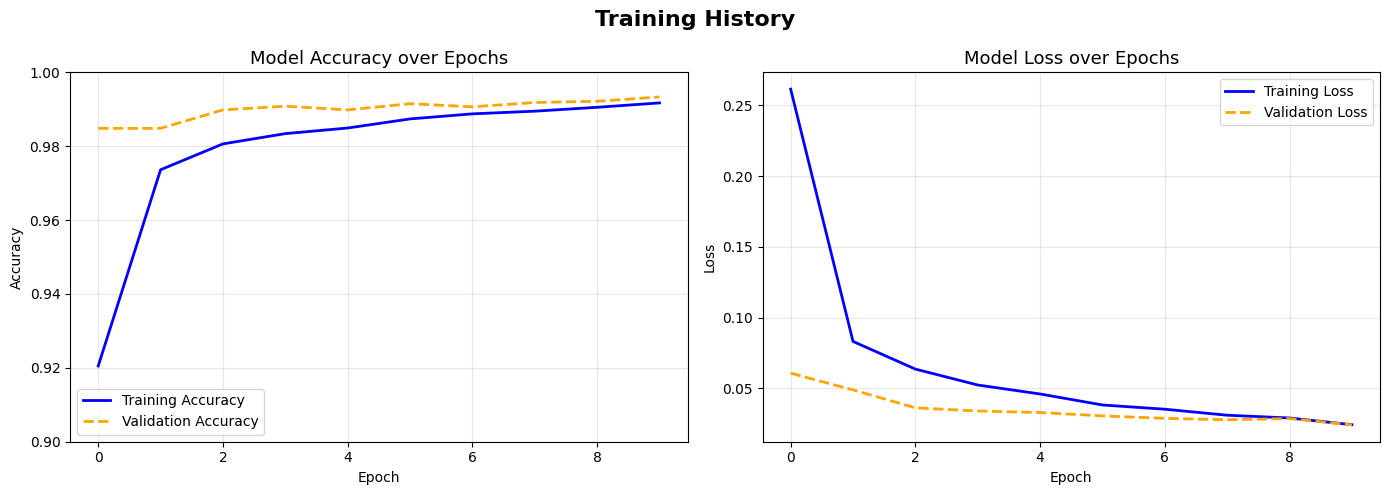

What to look for:
Good: Both curves go up/down together (model generalizes well)
Bad: Training much better than validation → Overfitting


In [ ]:
# Plot the training history
# This shows how the model improved over time

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Training Accuracy',   color='blue',   linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy over Epochs', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.9, 1.0])

# Loss plot
ax2.plot(history.history['loss'],     label='Training Loss',   color='blue',   linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax2.set_title('Model Loss over Epochs', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("What to look for:")
print("Good: Both curves go up/down together (model generalizes well)")
print("Bad: Training much better than validation → Overfitting")

## Part 8: Evaluating the Model

Now let's see how well the model does on the **test set** — images it has **never seen before**!

In [ ]:
# Evaluate on the test set

test_loss, test_accuracy = model.evaluate(x_test, y_test_ohe, verbose=0)

print("Test Set Results:")
print(f"Accuracy: {test_accuracy * 100:.2f}%")
print(f"Loss:     {test_loss:.4f}")
print()
print(f"This means the model correctly identifies {test_accuracy * 100:.1f}% of unseen digits!")
print(f"   With 10,000 test images, it got about {int(test_accuracy * 10000):,} correct.")

Test Set Results:
Accuracy: 99.27%
Loss:     0.0194

This means the model correctly identifies 99.3% of unseen digits!
   With 10,000 test images, it got about 9,926 correct.


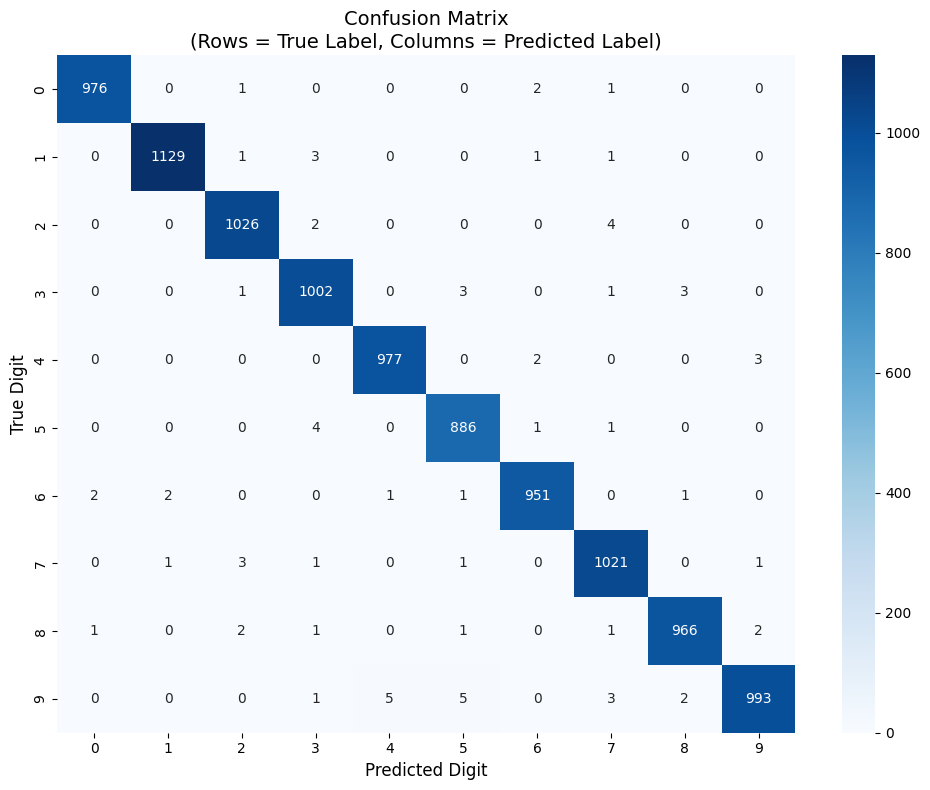

Reading the confusion matrix:
• The diagonal (top-left to bottom-right) = CORRECT predictions
• Off-diagonal entries = mistakes
• Example: If row 4, col 9 has a high number → model confused 4s with 9s


In [ ]:
# Confusion Matrix — see where the model makes mistakes

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
y_true = y_test  # original labels (not one-hot)

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix\n(Rows = True Label, Columns = Predicted Label)', fontsize=14)
plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('True Digit', fontsize=12)
plt.tight_layout()
plt.show()

print("Reading the confusion matrix:")
print("• The diagonal (top-left to bottom-right) = CORRECT predictions")
print("• Off-diagonal entries = mistakes")
print("• Example: If row 4, col 9 has a high number → model confused 4s with 9s")

## Part 9: Making Predictions

Let's see the model in action — predicting real images one by one!

/tmp/ipykernel_724/771010109.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


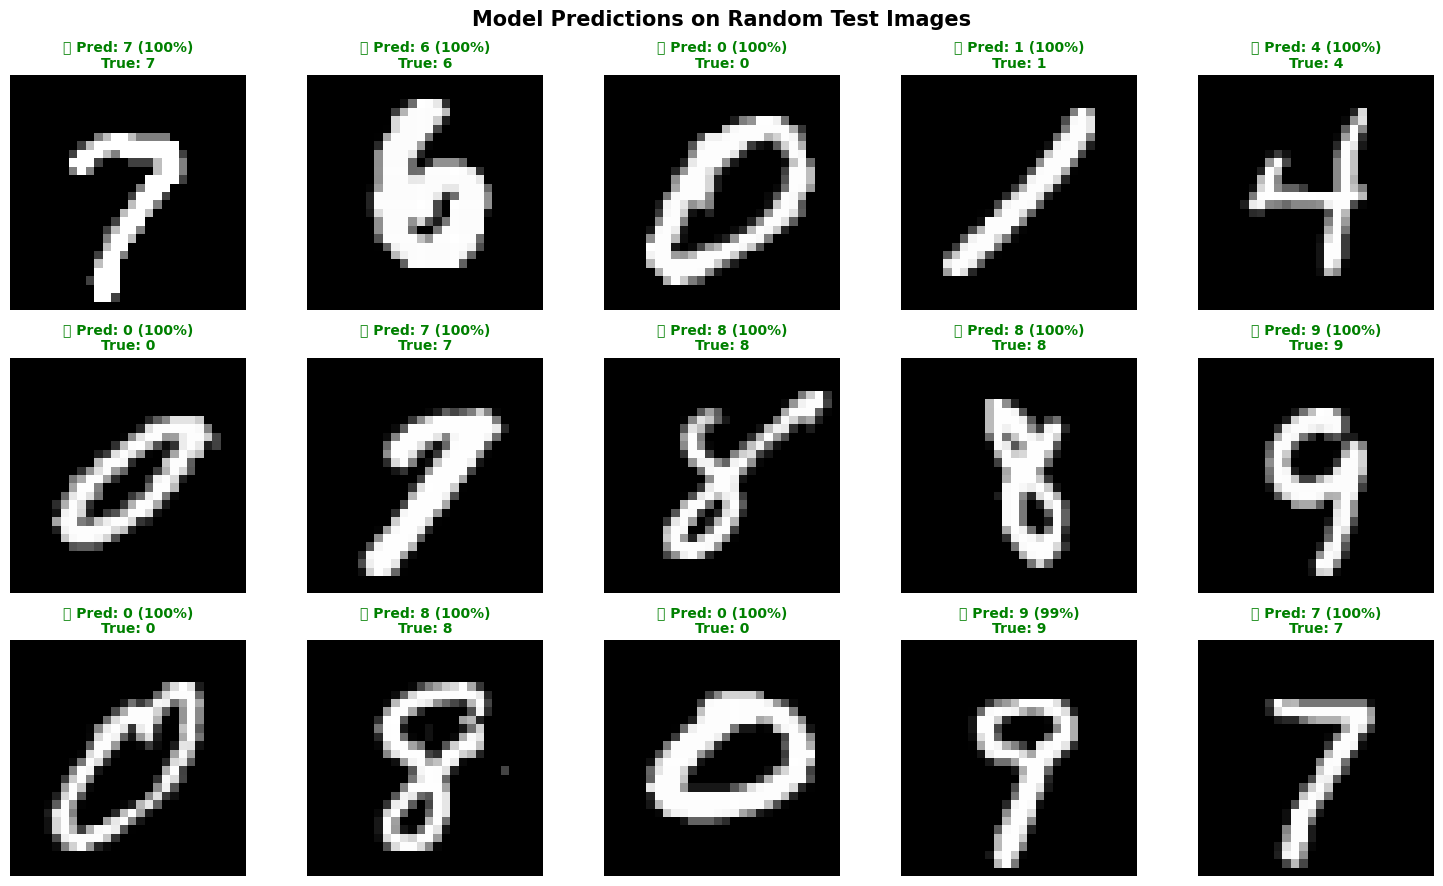

In [ ]:
# Make predictions on random test images

def predict_and_show(num_images=15):
    """Show random test images and the model's predictions."""

    # Pick random test images
    indices = np.random.choice(len(x_test), num_images, replace=False)

    # Get predictions (probabilities for each of 10 classes)
    predictions = model.predict(x_test[indices], verbose=0)

    # Plot
    cols = 5
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    fig.suptitle('Model Predictions on Random Test Images', fontsize=15, fontweight='bold')
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        image = x_test[idx]
        true_label = y_test[idx]
        pred_label = np.argmax(predictions[i])
        confidence = np.max(predictions[i]) * 100

        # Show image
        axes[i].imshow(image.reshape(28, 28), cmap='gray')

        # Color the title: green = correct, red = wrong
        color = 'green' if pred_label == true_label else 'red'
        icon  = '✅' if pred_label == true_label else '❌'

        axes[i].set_title(
            f'{icon} Pred: {pred_label} ({confidence:.0f}%)\nTrue: {true_label}',
            fontsize=10, color=color, fontweight='bold'
        )
        axes[i].axis('off')

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

predict_and_show(15)

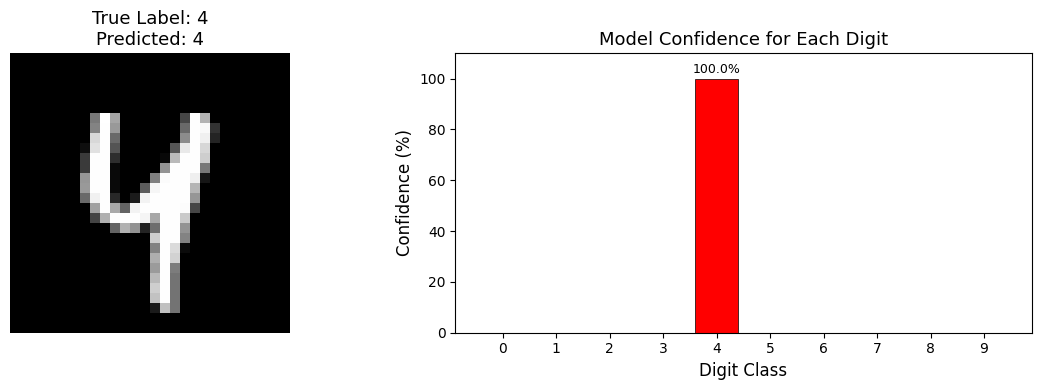

The model is 100.0% confident this is a '4'


In [ ]:
# Deep dive: See full probability distribution for one image

def show_probabilities(image_index=42):
    """Show how confident the model is for each digit class."""

    image = x_test[image_index:image_index+1]  # Keep batch dimension
    true_label = y_test[image_index]

    # Get probabilities
    probs = model.predict(image, verbose=0)[0]
    pred_label = np.argmax(probs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Show image
    ax1.imshow(image.reshape(28, 28), cmap='gray')
    ax1.set_title(f'True Label: {true_label}\nPredicted: {pred_label}', fontsize=13)
    ax1.axis('off')

    # Show probability bar chart
    colors = ['red' if i == pred_label else 'steelblue' for i in range(10)]
    bars = ax2.bar(range(10), probs * 100, color=colors, edgecolor='black', linewidth=0.5)
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Digit Class', fontsize=12)
    ax2.set_ylabel('Confidence (%)', fontsize=12)
    ax2.set_title('Model Confidence for Each Digit', fontsize=13)
    ax2.set_ylim(0, 110)

    # Add value labels on bars
    for bar, prob in zip(bars, probs):
        if prob > 0.005:
            ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"The model is {probs[pred_label]*100:.1f}% confident this is a '{pred_label}'")
    if pred_label != true_label:
        print(f"But the true answer is '{true_label}' — the model got this one wrong!")

# Change the index to explore different images (0 to 9999)
show_probabilities(image_index=42)

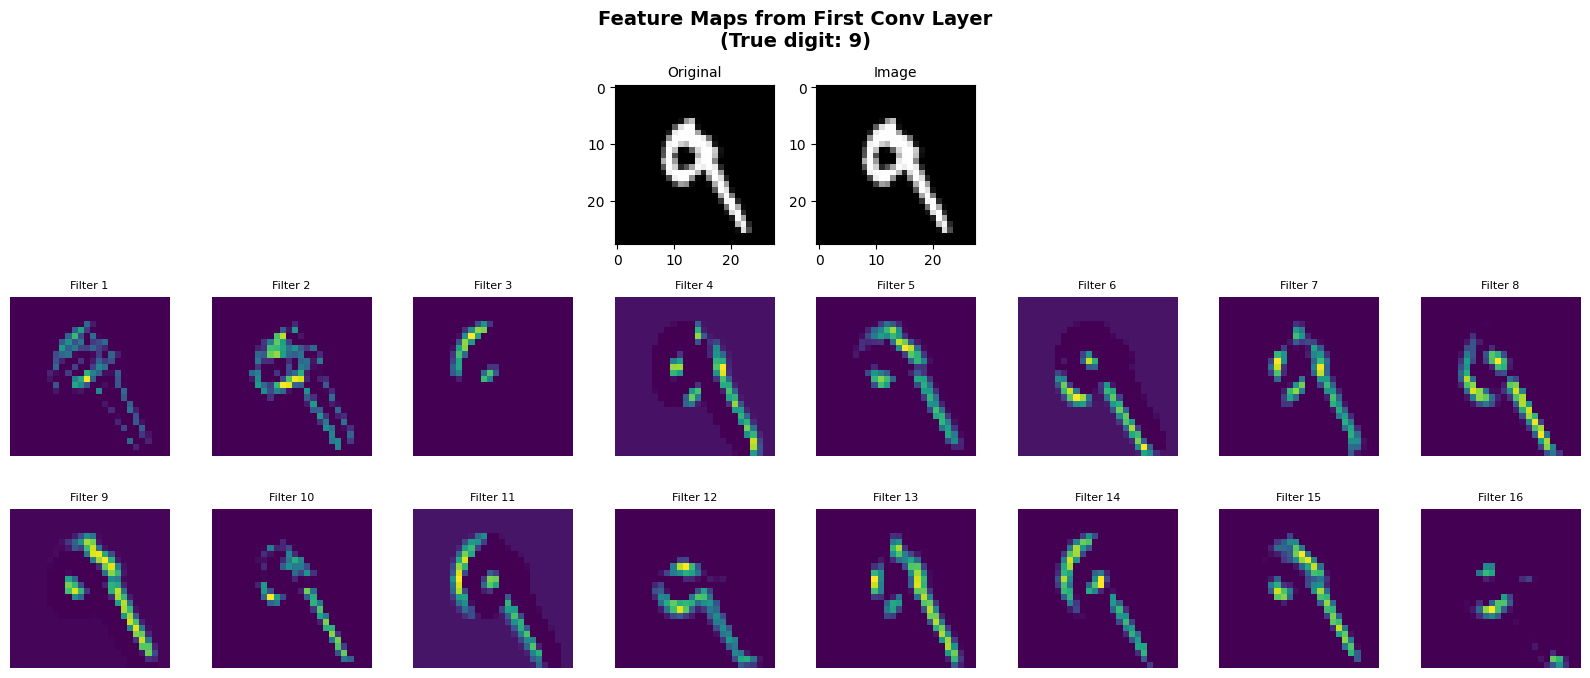

Each 'feature map' shows what a different filter detected!
Some filters detect vertical edges, others detect horizontal lines, curves, etc.


In [ ]:
# Visualize what the CNN "sees" — Feature Maps
# This shows what each convolutional filter detects!

# Build a model that outputs the first conv layer's activations
feature_model = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output  # First conv layer
)

# Pick one image
sample_idx = 7
sample_img = x_test[sample_idx:sample_idx+1]

# Get feature maps
feature_maps = feature_model.predict(sample_img, verbose=0)

# Plot first 16 feature maps
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle(f'Feature Maps from First Conv Layer\n(True digit: {y_test[sample_idx]})',
             fontsize=14, fontweight='bold')

# Original image
for ax in axes[0]:
    ax.axis('off')
axes[0, 3].imshow(sample_img.reshape(28, 28), cmap='gray')
axes[0, 3].set_title('Original', fontsize=10)
axes[0, 3].axis('on')
axes[0, 4].imshow(sample_img.reshape(28, 28), cmap='gray')
axes[0, 4].set_title('Image', fontsize=10)
axes[0, 4].axis('on')

# First 16 feature maps
for i in range(16):
    row = 1 + i // 8
    col = i % 8
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[row, col].set_title(f'Filter {i+1}', fontsize=8)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Each 'feature map' shows what a different filter detected!")
print("Some filters detect vertical edges, others detect horizontal lines, curves, etc.")

## Bonus: Save & Load the Model

In [ ]:
# Save the trained model
model.save('my_first_cnn.keras')
print("Model saved as 'my_first_cnn.keras'")

# Load it back
loaded_model = keras.models.load_model('my_first_cnn.keras')
print("Model loaded back successfully!")

# Quick check — does it still work?
_, acc = loaded_model.evaluate(x_test, y_test_ohe, verbose=0)
print(f"   Loaded model accuracy: {acc*100:.2f}% — same as before!")

Model saved as 'my_first_cnn.keras'
Model loaded back successfully!
   Loaded model accuracy: 99.27% — same as before!


What you think it's 3 or 8?

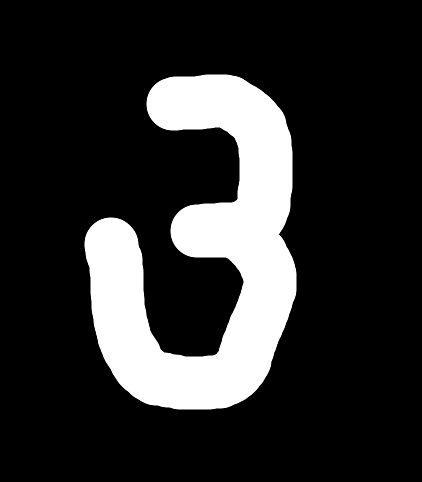

# Load and preprocess the test image

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the test image
test_img_path = '3.png'

img = image.load_img(test_img_path, color_mode='grayscale', target_size=(28, 28))
img_array = image.img_to_array(img)       # Shape: (28, 28, 1)
img_array = img_array / 255.0             # Normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0)  # Add batch dim → (1, 28, 28, 1)

# Predict
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

print(f"Predicted digit : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")
print(f"All class probs : {np.round(predictions[0], 3)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted digit : 3
Confidence      : 95.59%
All class probs : [0.    0.    0.044 0.956 0.    0.    0.    0.    0.    0.   ]


## Part 10: Summary & What's Next!

### What You Accomplished

Congratulations! You just built a CNN from scratch that:
- Learned from **60,000 handwritten digit images**
- Achieved **~99% accuracy** on unseen test data
- Can tell apart digits **0 through 9**

---

### What You Learned

| Concept | What it does |
|---------|-------------|
| `Conv2D` | Detects features (edges, shapes) using filters |
| `MaxPooling2D` | Shrinks feature maps, keeps strongest signals |
| `Dropout` | Prevents overfitting by randomly disabling neurons |
| `Flatten` | Converts 2D maps to 1D for dense layers |
| `Dense` | Fully connected layer for classification |
| `softmax` | Converts outputs to probabilities |
| `model.compile()` | Sets optimizer, loss, and metrics |
| `model.fit()` | Trains the model |
| `model.evaluate()` | Tests the model on unseen data |
| `model.predict()` | Makes predictions on new data |

---

### What's Next? (Your Learning Path)

1. **Try CIFAR-10** — Color images of animals and vehicles (harder!)
   ```python
   from tensorflow.keras.datasets import cifar10
   (x_train, y_train), (x_test, y_test) = cifar10.load_data()
   ```

2. **Use Transfer Learning** — Start with a pre-trained model (VGG16, ResNet, MobileNet)
   ```python
   base_model = keras.applications.MobileNetV2(weights='imagenet', include_top=False)
   ```

3. **Build an image classifier on YOUR own photos** — Use `ImageDataGenerator`

4. **Try Object Detection** — YOLO, Faster R-CNN (detect multiple objects in one image)

5. **Learn about other architectures**: VGG, ResNet, Inception, EfficientNet

---

### Free Resources

- 🌐 [TensorFlow Official Tutorials](https://www.tensorflow.org/tutorials)
- 📖 [Keras Documentation](https://keras.io/)
- 🎓 [Deep Learning Specialization — Coursera (Andrew Ng)](https://www.coursera.org/specializations/deep-learning)
- 📘 [Hands-On Machine Learning with Scikit-Learn and TensorFlow (Book)](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

---

> 💬 **Remember**: The best way to learn is to experiment! Try changing:
> - Number of filters in Conv2D layers
> - Number of Dense neurons
> - Dropout rate
> - Number of epochs
> - Adding more Conv layers
>
> **See how each change affects accuracy!**



---



In [ ]:
# Challenge: Try modifying this cell to experiment!
# Can you beat 99% accuracy?

# Ideas to try:
# 1. Add more Conv2D layers
# 2. Change the number of filters (32, 64, 128...)
# 3. Change Dropout rate (0.3, 0.5, 0.7)
# 4. Try different optimizers ('sgd', 'rmsprop', 'adam')
# 5. Increase epochs

print("Your turn! Modify the model above and see if you can improve accuracy.")
print("Current accuracy:", f"{test_accuracy*100:.2f}%")
print("\n Good luck!")

Your turn! Modify the model above and see if you can improve accuracy.
Current accuracy: 99.27%

 Good luck!
